# Exercice : Relation entre cas et décès par continent

## 1. Sélection du mois
Choisissez un mois pertinent, c’est-à-dire une période où le nombre de cas est suffisamment élevé pour permettre une analyse significative.  
Filtrez ensuite la base de données pour ne conserver que les observations correspondant à ce mois.

## 2. Identification du continent
Associer chaque pays à son continent, en utilisant la bibliothèque Python **`pycountry-convert`** ainsi que la fonction fournie dans la suite du cours.

## 3. Création du graphique
Réalisez un **nuage de points (scatter plot)** représentant la relation entre :  
- le **nombre de cas** (axe des x)  
- le **nombre de décès** (axe des y)  

Les points doivent être **différenciés par continent** (par couleur ou par forme).  
Le graphique doit être affiché en **échelle logarithmique** sur les deux axes afin de mieux visualiser les différences entre pays à faible et forte incidence.

### Installation des bibliothèques
```bash
pip install pycountry pycountry-convert


In [4]:
#fonction pour convertir un code ISO3 en continent

import pycountry_convert as pc

def iso3_to_continent(iso3):
    try:
         # convertir le code ISO3 en code ISO2
        iso2 = pc.country_alpha3_to_country_alpha2(iso3)
        # convertir ISO2 en code de continent (EU, AF, AS, NA, SA, OC)
        continent_code = pc.country_alpha2_to_continent_code(iso2)
        # convertir le code de continent en nom complet
        continent_name = pc.convert_continent_code_to_continent_name(continent_code)
    except:
        continent_name = 'Unknown'
    
    return continent_name

#exemples d'utilisation
print(iso3_to_continent('FRA'))  # Europe
print(iso3_to_continent('BRA'))  # South America
print(iso3_to_continent('PNC'))  

Europe
South America
Unknown


In [7]:
iso3_to_continent('BRA')

'South America'

In [1]:
# importation des bibliothèques nécessaires
import pandas as pd
import pycountry_convert as pc
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#importer la base de données COVID-19
import pandas as pd
df=pd.read_csv('../data/data_covid.csv')

In [3]:
df

,Entity,Code,Day,Deaths,Cases
0,Afghanistan,AFG,2020-01-09,0.0,0.0
1,Afghanistan,AFG,2020-01-10,0.0,0.0
2,Afghanistan,AFG,2020-01-11,0.0,0.0
3,Afghanistan,AFG,2020-01-12,0.0,0.0
4,Afghanistan,AFG,2020-01-13,0.0,0.0
...,...,...,...,...,...
511288,Zimbabwe,ZWE,2026-01-28,0.0,0.0
511289,Zimbabwe,ZWE,2026-01-29,0.0,0.0
511290,Zimbabwe,ZWE,2026-01-30,0.0,0.0
511291,Zimbabwe,ZWE,2026-01-31,0.0,0.0


In [8]:
# Convertir la colonne 'Day' en format datetime
df['Date'] = pd.to_datetime(df['Day'])

In [6]:
df

,Entity,Code,Day,Deaths,Cases,Date
0,Afghanistan,AFG,2020-01-09,0.0,0.0,2020-01-09
1,Afghanistan,AFG,2020-01-10,0.0,0.0,2020-01-10
2,Afghanistan,AFG,2020-01-11,0.0,0.0,2020-01-11
3,Afghanistan,AFG,2020-01-12,0.0,0.0,2020-01-12
4,Afghanistan,AFG,2020-01-13,0.0,0.0,2020-01-13
...,...,...,...,...,...,...
511288,Zimbabwe,ZWE,2026-01-28,0.0,0.0,2026-01-28
511289,Zimbabwe,ZWE,2026-01-29,0.0,0.0,2026-01-29
511290,Zimbabwe,ZWE,2026-01-30,0.0,0.0,2026-01-30
511291,Zimbabwe,ZWE,2026-01-31,0.0,0.0,2026-01-31


In [9]:
# Extraire le mois et l'année de la colonne 'Date' et les stocker dans une nouvelle colonne 'month_year'
df['month_year'] = df['Date'].dt.to_period('M')

In [10]:
df

,Entity,Code,Day,Deaths,Cases,Date,month_year
0,Afghanistan,AFG,2020-01-09,0.0,0.0,2020-01-09,2020-01
1,Afghanistan,AFG,2020-01-10,0.0,0.0,2020-01-10,2020-01
2,Afghanistan,AFG,2020-01-11,0.0,0.0,2020-01-11,2020-01
3,Afghanistan,AFG,2020-01-12,0.0,0.0,2020-01-12,2020-01
4,Afghanistan,AFG,2020-01-13,0.0,0.0,2020-01-13,2020-01
...,...,...,...,...,...,...,...
511288,Zimbabwe,ZWE,2026-01-28,0.0,0.0,2026-01-28,2026-01
511289,Zimbabwe,ZWE,2026-01-29,0.0,0.0,2026-01-29,2026-01
511290,Zimbabwe,ZWE,2026-01-30,0.0,0.0,2026-01-30,2026-01
511291,Zimbabwe,ZWE,2026-01-31,0.0,0.0,2026-01-31,2026-01


In [11]:
# Filtrer les données pour ne garder que celles du mois de janvier 2021
df_month=df[df['month_year']=='2021-03']

In [12]:
df_month

,Entity,Code,Day,Deaths,Cases,Date,month_year
417,Afghanistan,AFG,2021-03-01,1.571428,16.571428,2021-03-01,2021-03
418,Afghanistan,AFG,2021-03-02,1.571428,16.142857,2021-03-02,2021-03
419,Afghanistan,AFG,2021-03-03,1.428572,15.142858,2021-03-03,2021-03
420,Afghanistan,AFG,2021-03-04,1.142857,13.571428,2021-03-04,2021-03
421,Afghanistan,AFG,2021-03-05,1.000000,18.714285,2021-03-05,2021-03
...,...,...,...,...,...,...,...
509520,Zimbabwe,ZWE,2021-03-27,1.142857,21.857143,2021-03-27,2021-03
509521,Zimbabwe,ZWE,2021-03-28,1.285714,22.285715,2021-03-28,2021-03
509522,Zimbabwe,ZWE,2021-03-29,1.142857,22.428572,2021-03-29,2021-03
509523,Zimbabwe,ZWE,2021-03-30,0.857143,22.142857,2021-03-30,2021-03


In [10]:
iso3_to_continent('AFG')

'Asia'

In [13]:
# Ajouter une colonne 'Continent' en appliquant la fonction iso3_to_continent à la colonne 'Code'
df_month['Continent'] = df_month['Code'].apply(iso3_to_continent)    

/var/folders/1n/j534p4sn2yl7fgjy8bv2l5zm0000gn/T/ipykernel_6115/3899351819.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_month['Continent'] = df_month['Code'].apply(iso3_to_continent)


In [14]:
df_month

,Entity,Code,Day,Deaths,Cases,Date,month_year,Continent
417,Afghanistan,AFG,2021-03-01,1.571428,16.571428,2021-03-01,2021-03,Asia
418,Afghanistan,AFG,2021-03-02,1.571428,16.142857,2021-03-02,2021-03,Asia
419,Afghanistan,AFG,2021-03-03,1.428572,15.142858,2021-03-03,2021-03,Asia
420,Afghanistan,AFG,2021-03-04,1.142857,13.571428,2021-03-04,2021-03,Asia
421,Afghanistan,AFG,2021-03-05,1.000000,18.714285,2021-03-05,2021-03,Asia
...,...,...,...,...,...,...,...,...
509520,Zimbabwe,ZWE,2021-03-27,1.142857,21.857143,2021-03-27,2021-03,Africa
509521,Zimbabwe,ZWE,2021-03-28,1.285714,22.285715,2021-03-28,2021-03,Africa
509522,Zimbabwe,ZWE,2021-03-29,1.142857,22.428572,2021-03-29,2021-03,Africa
509523,Zimbabwe,ZWE,2021-03-30,0.857143,22.142857,2021-03-30,2021-03,Africa


In [15]:
df_month['Continent'].value_counts()

Continent
Africa           1736
Europe           1488
Asia             1457
North America    1240
Oceania           713
South America     434
Unknown           124
Name: count, dtype: int64

In [16]:
#Supprimer les lignes où le continent est inconnu
df_month=df_month[df_month['Continent']!='Unknown']

In [41]:
df_month

,Entity,Code,Day,Deaths,Cases,Date,month_year,Continent
417,Afghanistan,AFG,2021-03-01,1.571428,16.571428,2021-03-01,2021-03,Asia
418,Afghanistan,AFG,2021-03-02,1.571428,16.142857,2021-03-02,2021-03,Asia
419,Afghanistan,AFG,2021-03-03,1.428572,15.142858,2021-03-03,2021-03,Asia
420,Afghanistan,AFG,2021-03-04,1.142857,13.571428,2021-03-04,2021-03,Asia
421,Afghanistan,AFG,2021-03-05,1.000000,18.714285,2021-03-05,2021-03,Asia
...,...,...,...,...,...,...,...,...
509520,Zimbabwe,ZWE,2021-03-27,1.142857,21.857143,2021-03-27,2021-03,Africa
509521,Zimbabwe,ZWE,2021-03-28,1.285714,22.285715,2021-03-28,2021-03,Africa
509522,Zimbabwe,ZWE,2021-03-29,1.142857,22.428572,2021-03-29,2021-03,Africa
509523,Zimbabwe,ZWE,2021-03-30,0.857143,22.142857,2021-03-30,2021-03,Africa


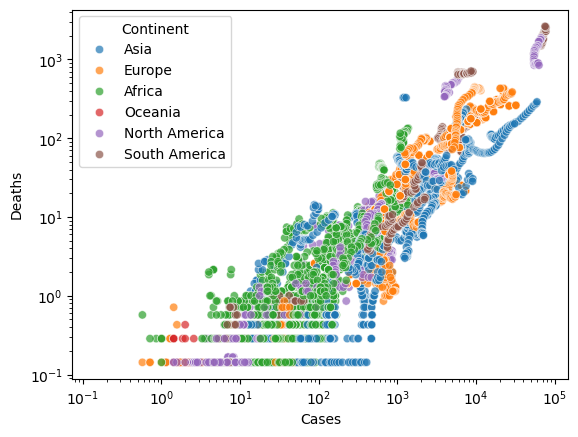

In [17]:
#plot in log-log scale
sns.scatterplot(data=df_month, x='Cases', y='Deaths', hue='Continent', alpha=0.7)   
plt.xscale('log')
plt.yscale('log') 
plt.show()

In [23]:
df_month_group=df_month.groupby(['Entity', 'Continent'])[['Cases', 'Deaths']].sum()

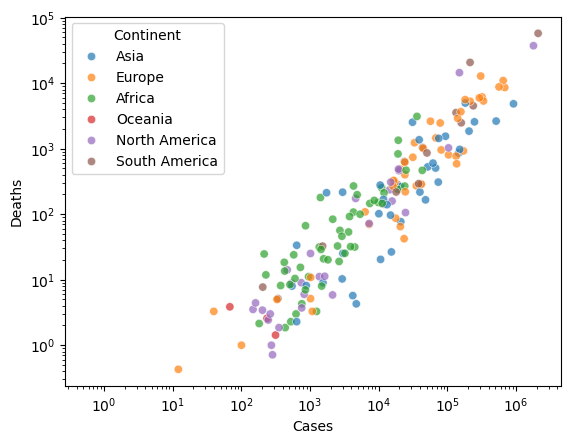

In [24]:
#plot in log-log scale
sns.scatterplot(data=df_month_group, x='Cases', y='Deaths', hue='Continent', alpha=0.7)   
plt.xscale('log')
plt.yscale('log') 
plt.show()

# Exercice 2 : Analyse des données Reddit "incel"

### 1. Importer la base de données
- Charger le dataset `incel` sans text dans un DataFrame pandas.
- Vérifier les colonnes disponibles

### 2. Graphique de composition
- Réaliser un **graphique de composition**  pour montrer la **répartition des posts entre les différents subreddits**.


### 3. Wordcloud pour un subreddit
- Choisir un **subreddit spécifique**.  
- Importer la base de données relative au sub-reddit choisi
- Agréger tous les textes (`text`) de ce subreddit en un seul bloc.  
- Nettoyer le texte si nécessaire (suppression de stopwords, ponctuation, etc.).  
- Créer un **wordcloud** pour visualiser les mots les plus fréquents et leur importance relative.




In [25]:
infile='../data/reddit_no_text.csv'

In [ ]:
df=pd.read_csv(infile,nrows=1000000)

In [27]:
df

,author,date,id_post,subreddit
0,333876225,1546300841,abcuq9,depression
1,rebelarch86,1546300848,abcurw,RedPillWives
2,Handheld_Gaming,1546300852,abcusl,Braincels
3,DimoneFreehold20,1546300863,abcuuq,MGTOW
4,Miss_Defined,1546300883,abcuzf,ForeverAlone
...,...,...,...,...
29482382,[deleted],1246405038,c0apkcu,MensRights
29482383,[deleted],1246405118,c0apke4,MensRights
29482384,ladyskins,1246405258,c0apkfz,MensRights
29482385,[deleted],1246405474,c0apkj7,MensRights


In [90]:
df_result = df.groupby('subreddit')['id_post'].count().reset_index()
df_result.columns = ['subreddit', 'number_of_post']

In [91]:
df_result


,subreddit,number_of_post
0,BlackPillScience,9048
1,Braincels,2830522
2,Egalitarianism,26520
3,ForeverAlone,1921363
4,ForeverAloneDating,153039
5,ForeverUnwanted,24855
6,Foreveralonelondon,57
7,GEOTRP,350
8,Gold_Digger,435
9,IncelDense,2058


In [29]:
df.columns

Index(['author', 'date', 'id_post', 'subreddit'], dtype='object')

In [ ]:
#option1
df.groupby('subreddit')['id_post'].count().reset_index().rename(columns={'id_post': 'post_count'})

In [89]:
#option2
df_subreddit =df.value_counts('subreddit').reset_index().rename(columns={'count': 'post_count'})

In [32]:
df_subreddit.to_csv('../data/reddit_subreddit_counts.csv', index=False)

In [93]:
import plotly.express as px

fig = px.treemap(
    df_subreddit,
    path=["subreddit"],
    values="post_count",
    title="Répartition des posts par subreddit",
    width=800,   # largeur en pixel
    height=600   # hauteur en pixel
)

fig.show()

In [34]:
infile='../data/PhilosophyOfRape.csv'
dft=pd.read_csv(infile)

In [ ]:
dft


,author,date,text
0,seamitten,1411895214,Jesus christ where am I?!
1,Son_of_Sophroniscus,1412075083,/r/theredpill --------------&gt;
2,ThePhilosophyOfRape,1412083243,Those shameless pussy beggars don't have an ou...
3,Son_of_Sophroniscus,1412083473,What do you mean? Here are two from the front...
4,gepeg-libre,1412095195,Kill yourself. Before it's too late.
...,...,...,...
1111,DreamsofEden,1424756341,There IS a thinly veiled confession - he has a...
1112,[deleted],1424820314,[deleted]
1113,KrustyKoonKrackers,1424826485,Removed. This is not /r/circlejerk.
1114,jgup123,1424890546,Someone you don't know needs to take their dic...


In [35]:
dft['text']

0                               Jesus christ where am I?!
1                        /r/theredpill --------------&gt;
2       Those shameless pussy beggars don't have an ou...
3       What do you mean?  Here are two from the front...
4                   Kill yourself. Before it's too late. 
                              ...                        
1111    There IS a thinly veiled confession - he has a...
1112                                            [deleted]
1113                 Removed. This is not /r/circlejerk. 
1114    Someone you don't know needs to take their dic...
1115    I've been doing a lot of soul searching these ...
Name: text, Length: 1116, dtype: object

In [42]:
len(dft)

1116

In [ ]:
dftfiltr=dft[~dft['text'].isna()]


In [41]:
dft.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1116 entries, 0 to 1115
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   author  1116 non-null   object
 1   date    1116 non-null   int64 
 2   text    1116 non-null   object
dtypes: int64(1), object(2)
memory usage: 26.3+ KB


In [37]:
docs=' '.join(list(dft['text']))

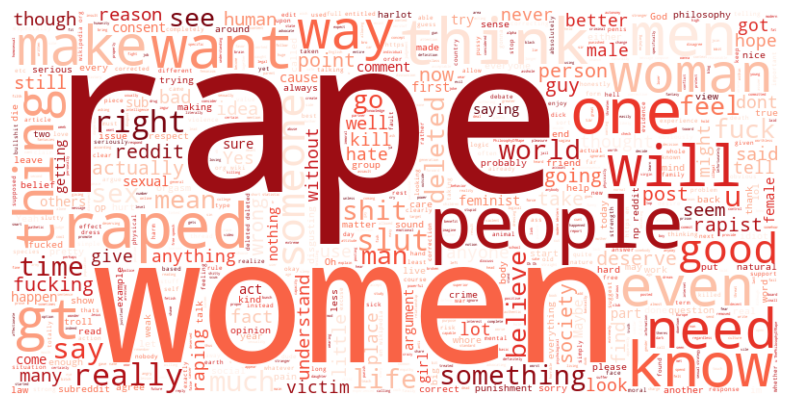

In [44]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt


# 2. Creer le WordCloud
wordcloud = WordCloud(
    width=800,        # largeur de l'image
    height=400,       # hauteur de l'image
    background_color='white', # couleur de fond
    colormap='Reds',       # palette de couleurs
    max_words=1000,    # nombre maximum de mots
).generate(docs)

# 3. Affichons le WordCloud
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # supprimons les axes
plt.show()

# Exercice 3 : Analyse temporelle des subreddits

### 1. Profil temporel des subreddits principaux
- Identifier les **subreddits principaux** (les plus fréquents ou les plus actifs).  
- Créer un **graphique temporel** (line plot) montrant l’évolution du nombre de posts pour chaque subreddit au fil du temps.  
- L’axe des x peut représenter **les jours ou les mois**, et l’axe des y le **nombre de posts**.

### 2. Activité par heure de la journée
- Selectionner 3 subreddit
- Extraire l’**heure de publication** de chaque post à partir de la colonne timestamp.  
- Agréger le nombre de posts **par heure et par subreddit**.  
- Visualiser un **graphique à barres empilées** ou groupées montrant le nombre de posts par heure pour chaque subreddit.  
- Cela permet d’identifier les **heures de pointe** pour chaque communauté.

In [45]:
df['date'] = pd.to_datetime(df['date'], unit='s')

In [46]:
df['hour'] = df['date'].dt.hour

In [75]:
counts=df.value_counts('subreddit')

In [76]:
listOfLarge=counts[counts>50000].index.tolist()

In [65]:
dfLarge=df[df['subreddit'].isin(listOfLarge)]

In [70]:
dfLarge

,author,date,id_post,subreddit,hour
0,333876225,2019-01-01 00:00:41,abcuq9,depression,0
1,rebelarch86,2019-01-01 00:00:48,abcurw,RedPillWives,0
2,Handheld_Gaming,2019-01-01 00:00:52,abcusl,Braincels,0
3,DimoneFreehold20,2019-01-01 00:01:03,abcuuq,MGTOW,0
4,Miss_Defined,2019-01-01 00:01:23,abcuzf,ForeverAlone,0
...,...,...,...,...,...
29482382,[deleted],2009-06-30 23:37:18,c0apkcu,MensRights,23
29482383,[deleted],2009-06-30 23:38:38,c0apke4,MensRights,23
29482384,ladyskins,2009-06-30 23:40:58,c0apkfz,MensRights,23
29482385,[deleted],2009-06-30 23:44:34,c0apkj7,MensRights,23


/var/folders/1n/j534p4sn2yl7fgjy8bv2l5zm0000gn/T/ipykernel_6115/173876552.py:35: UserWarning:

Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.



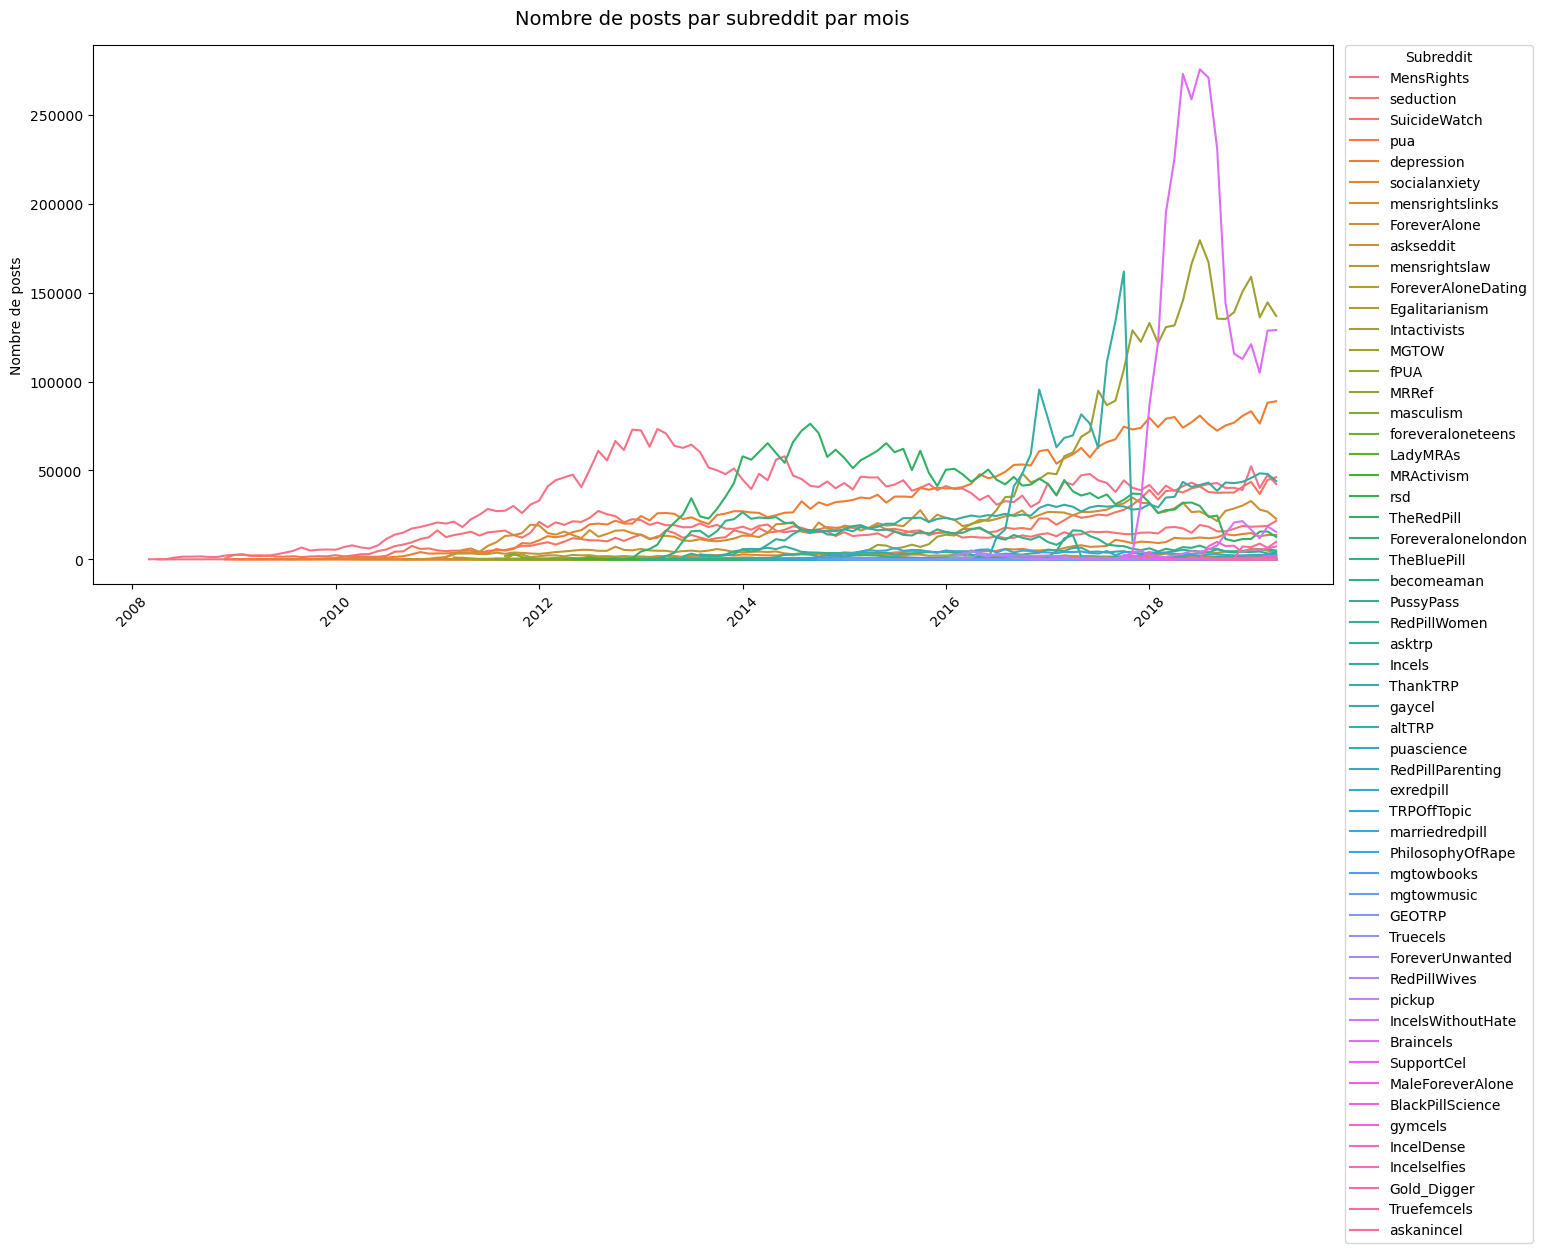

In [77]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Préparation des données
df['date'] = pd.to_datetime(df['date'])
df['period'] = df['date'].dt.to_period('M').dt.to_timestamp()

# 2. Agrégation : compte de posts par mois et subreddit
counts = (
    df
    .groupby(['period', 'subreddit'])
    .size()
    .reset_index(name='n_posts')
)

# 3. Plot
plt.figure(figsize=(16, 7))

ax = sns.lineplot(
    data=counts,
    x='period',
    y='n_posts',
    hue='subreddit',
    linewidth=1.5,
)

# Mise en forme
ax.set_title('Nombre de posts par subreddit par mois', fontsize=14, pad=15)
ax.set_xlabel('')
ax.set_ylabel('Nombre de posts')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Subreddit', bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)

plt.tight_layout()
plt.show()

In [78]:
import plotly.express as px
# 3. Plot
fig = px.line(
    counts,
    x='period',
    y='n_posts',
    color='subreddit',
    title='Nombre de posts par subreddit par mois',
    labels={'period': '', 'n_posts': 'Nombre de posts', 'subreddit': 'Subreddit'},
)

fig.update_layout(
    width=1100,
    height=550,
    hovermode='x unified',        # tooltip groupé par date
    legend=dict(
        title='Subreddit',
        bgcolor='rgba(0,0,0,0)',
    )
)

fig.show()

In [79]:
fig = px.line(
    counts,
    x='period',
    y='n_posts',
    color='subreddit',
    title='Nombre de posts par subreddit par mois',
    labels={'period': '', 'n_posts': 'Nombre de posts', 'subreddit': 'Subreddit'},
    hover_name='subreddit',        # ← nom du subreddit en titre du tooltip
    hover_data={'subreddit': False} # ← évite la répétition dans le corps
)

fig.update_layout(
    hovermode='closest',           # ← tooltip sur la ligne la plus proche
)

fig.show()